## Session 5 — Deep Learning & NLP Taste

## Module 8 — Intro to Neural Networks

**Learning Objective**: Build one very small neural network and understand, conceptually, what CNN/RNN/DBN add on top.

📘 **Perceptrons and Multilayer Perceptrons (MLP)**

Imagine a single neuron in your brain receiving signals from other neurons. If the sum of these signals reaches a certain threshold, the neuron "fires" and sends its own signal onward. This is the basic idea behind a **perceptron**, the simplest form of a neural network.

However, a single perceptron can only solve very simple problems (like separating linearly separable data). Real biological systems and complex AI tasks require more sophisticated processing. This is where **Multilayer Perceptrons (MLPs)** come in. MLPs are composed of multiple layers of perceptrons, where the output of one layer serves as the input to the next. These layers are called "hidden layers" because they are not directly exposed to the input or output data. Each connection between neurons has a "weight" associated with it, which the network learns to adjust during training to make better predictions. This architecture allows MLPs to learn complex, non-linear relationships in data, much like how different regions of the brain specialize in processing various types of information and then integrate them to form a complete perception.

In bioinformatics, MLPs can be used for tasks like classifying disease states based on gene expression profiles or predicting protein functions from sequence data, learning intricate patterns that simple linear models might miss.

📘 **Convolutional Neural Networks (CNNs)**

While MLPs are powerful, they treat all input features equally. For data with spatial structure, like images (e.g., histology slides, microscopy images), this isn't ideal. **Convolutional Neural Networks (CNNs)** are specifically designed to process grid-like data. They use "convolutional layers" that apply a small filter (like a magnifying glass scanning across a slide) to detect local patterns such as edges, textures, or specific motifs. These detected patterns are then combined in later layers to recognize more complex structures. "Pooling layers" then reduce the spatial dimensions, helping to make the network robust to small shifts or distortions in the input.

🔬 **Why this matters in biology**: CNNs are revolutionizing medical imaging, enabling automated diagnosis of diseases from X-rays, MRIs, and pathology slides. For example, a CNN can be trained to count cells, identify cancerous regions in tissue biopsies, or even classify different types of bacteria from microscope images, mimicking how a human pathologist systematically scans and interprets visual information but with potentially greater speed and consistency.

📘 **Recurrent Neural Networks (RNNs)**

For data with sequential structure, such as DNA sequences, protein sequences, or time-series measurements (e.g., physiological sensor data), the order of information is crucial. **Recurrent Neural Networks (RNNs)** are designed to handle such data by having "memory." Unlike MLPs or CNNs, RNNs pass information from one step in the sequence to the next, allowing them to capture dependencies and context over time. Imagine reading a DNA sequence base by base; an RNN would remember the previous bases to interpret the current one in context.

🔬 **Why this matters in biology**: RNNs are particularly useful in genomics for tasks like predicting regulatory elements in DNA, classifying protein domains, or analyzing longitudinal patient data to forecast disease progression. They can identify patterns in sequences that are critical for understanding biological function and evolution.

📘 **Deep Belief Networks (DBNs)**

Before the rise of modern deep learning architectures like advanced CNNs and RNNs, **Deep Belief Networks (DBNs)** were a significant breakthrough in unsupervised learning and generative models. They are composed of multiple layers of "Restricted Boltzmann Machines" (RBMs) stacked on top of each other. DBNs were important for demonstrating how deep neural networks could be effectively pre-trained layer by layer, then fine-tuned for specific tasks. While less commonly used today for direct task solving, they laid much of the theoretical and practical groundwork for the deep learning revolution.

Now, let's build a simple Multilayer Perceptron (MLP) using `MLPClassifier` from `scikit-learn`.

In [ ]:
# Load necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### Dataset: Breast Cancer

We will reuse the Breast Cancer dataset, which is suitable for binary classification and has features that benefit from scaling, making it a good candidate for demonstrating an MLP.

In [ ]:
# Load the Breast Cancer dataset
breast_cancer = load_breast_cancer()
X = breast_cancer.data
y = breast_cancer.target

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Feature names: {breast_cancer.feature_names[:5]}...")

Features shape: (569, 30)
Target shape: (569,)
Number of classes: 2
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']...


### Data Preprocessing: Scaling and Train/Test Split

Just like with other machine learning models, neural networks often perform best when input features are scaled. We'll standardize the features and then split the data into training and testing sets to prevent data leakage.

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (455, 30)
Testing data shape: (114, 30)


📘 **Training, Validation, and Test Sets -- Why Two Splits Aren't Enough**

So far in this notebook series, a train/test split has been enough: fit on the training data, report one honest score on test data you never touched during training. Neural networks add a wrinkle that makes a two-way split insufficient.

Training an MLP is not a one-shot fit like `LogisticRegression.fit()`. It runs for many **epochs**, and at each epoch you have to answer a question the model cannot answer for itself: has it learned enough, or is it starting to memorize the training data instead of learning general patterns? Answering that requires checking performance on data the model was not trained on. If you use your test set to answer it, information from the test set quietly leaks into your training process. Your final test accuracy is no longer an honest, one-time exam score, it becomes the average of many peeks, and it will be optimistically biased.

The fix is a third split: the **validation set**. Think of it as practice quizzes during the semester, used to decide things like when to stop training, while the **test set** remains the one final exam, sat exactly once, after every decision about the model has already been made.

* **Training set**: what the model directly learns from, adjusting its weights against.
* **Validation set**: held out from training, checked periodically to decide when to stop (or which settings to prefer). Never used to update weights directly.
* **Test set**: touched exactly once, after training and all decisions are finalized, to report an honest, unbiased estimate of real-world performance.

You have actually already been using a validation set without seeing it. The `early_stopping=True` parameter in the `MLPClassifier` call below automatically carves a slice out of your *training* data as an internal validation set, and halts training once that validation score stops improving for `n_iter_no_change` epochs in a row. The cell below makes this three-way split visible for the first time.

🔬 **Why this matters in biology**: Imagine reporting a diagnostic model's accuracy after repeatedly checking your decision threshold against the same patient cohort you are about to report that accuracy on. The number would be inflated, and a clinician relying on it would be misled about real-world performance. Keeping a validation set strictly separate from the test set is what stands between a defensible accuracy claim and an inflated one.

⚠️ **Common mistake**: Always perform `fit_transform` on the training data and `transform` *only* on the test data. If you `fit_transform` on the entire dataset before splitting, information from the test set (like its mean and standard deviation) will leak into the training process, leading to an over-optimistic evaluation of your model's performance on unseen data. This is especially critical for neural networks which are highly sensitive to input scale.

### Task: Train an MLP Classifier

We will train a simple `MLPClassifier`. Key parameters include:
*   `hidden_layer_sizes`: A tuple defining the number of neurons in each hidden layer. For example, `(100,)` means one hidden layer with 100 neurons. `(50, 50)` means two hidden layers, each with 50 neurons.
*   `max_iter`: The maximum number of training iterations (epochs).
*   `activation`: The activation function for the hidden layer (e.g., 'relu', 'tanh', 'logistic').
*   `solver`: The algorithm for weight optimization (e.g., 'adam', 'sgd'). More on exactly what this optimizes just below.
*   `validation_fraction`: The proportion of the *training* data set aside internally as the validation set described above, used only when `early_stopping=True`. We set this explicitly below so the three-way split is visible rather than a hidden default.
*   `random_state`: For reproducibility.

In [ ]:
# Initialize and train the MLP Classifier
# validation_fraction is now explicit: 15% of the TRAINING data is held out internally
# as a validation set, used only to decide when early stopping should trigger.
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, activation='relu', solver='adam',
                     random_state=42, verbose=False, early_stopping=True, n_iter_no_change=50,
                     validation_fraction=0.15)
mlp.fit(X_train_scaled, y_train)

# Make the resulting three-way split concrete
n_total = X_train_scaled.shape[0] + X_test_scaled.shape[0]
n_internal_val = int(round(X_train_scaled.shape[0] * 0.15))
n_internal_train = X_train_scaled.shape[0] - n_internal_val
print(f"Total samples: {n_total}")
print(f"  Test set (touched once, at the very end):      {X_test_scaled.shape[0]} samples")
print(f"  Training set, before internal validation split: {X_train_scaled.shape[0]} samples")
print(f"    -> Internal training subset used to update weights: ~{n_internal_train} samples")
print(f"    -> Internal validation subset used for early stopping: ~{n_internal_val} samples")

# Plot the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(mlp.loss_curve_)
plt.title('MLP Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Make predictions and evaluate accuracy
y_pred = mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"MLP Classifier Accuracy: {accuracy:.4f}")

# Display confusion matrix
cm = confusion_matrix(y_test, y_pred)
cmd_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=breast_cancer.target_names)
fig, ax = plt.subplots(figsize=(6, 6))
cmd_display.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('MLP Confusion Matrix')
plt.show()

📘 **How Does a Neural Network Actually Learn? Weight Optimization and Gradient Descent**

Look back at the loss curve you just plotted. Every point on that curve is the result of one **epoch** of the same four-step loop, repeated automatically by `.fit()`:

1.  **Forward pass**: the network takes a batch of training samples and pushes them through its layers, weight by weight, to produce a prediction.
2.  **Compute the loss**: the prediction is compared to the true label using a loss function, producing a single number that measures how wrong the network currently is.
3.  **Backpropagation**: the network works backward through its layers, calculating exactly how much each individual weight contributed to that error. This is a direct application of the chain rule from calculus, but you never need to compute it by hand, `.fit()` does it automatically.
4.  **Weight update (the `solver`)**: each weight is nudged a small step in the direction that would have reduced the error, and the loop repeats.

This process, of following the slope of the error downhill toward a minimum, is called **gradient descent**. The `solver` parameter is simply which specific strategy is used to take that step: `'sgd'` takes a straightforward step based on the current gradient, while `'adam'` (the default here) adapts its step size per-weight based on recent history, which is usually why it converges faster and needs less manual tuning.

A steadily decreasing loss curve is the direct, visible signature of this process working correctly. A loss curve that plateaus or bounces around is telling you something about how well this four-step loop is going, which is exactly what the next section explores.

🎯 **Predict→Run→Interpret: Does Validation-Driven Early Stopping Matter?**

Before running the cell below, predict: if we train an identical MLP but with `early_stopping=False` (forcing it to run the full `max_iter=500` epochs regardless of what an internal validation score is doing), do you expect its test accuracy to be higher, lower, or about the same as the model above? What do you expect its loss curve to look like by comparison?

#### My Prediction:
*(Write your prediction here, and your reasoning, before running the cell below.)*

In [ ]:
# Train an identical MLP, but WITHOUT early stopping (no internal validation check)
mlp_no_early_stop = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, activation='relu',
                                   solver='adam', random_state=42, verbose=False,
                                   early_stopping=False)
mlp_no_early_stop.fit(X_train_scaled, y_train)

y_pred_no_es = mlp_no_early_stop.predict(X_test_scaled)
accuracy_no_es = accuracy_score(y_test, y_pred_no_es)

print(f"With early stopping (validation-driven):    {accuracy:.4f}  ({len(mlp.loss_curve_)} epochs run)")
print(f"Without early stopping (ran full max_iter):  {accuracy_no_es:.4f}  ({len(mlp_no_early_stop.loss_curve_)} epochs run)")

plt.figure(figsize=(10, 6))
plt.plot(mlp.loss_curve_, label=f'With early stopping ({len(mlp.loss_curve_)} epochs)')
plt.plot(mlp_no_early_stop.loss_curve_, label=f'Without early stopping ({len(mlp_no_early_stop.loss_curve_)} epochs)')
plt.title('Loss Curve: With vs. Without Validation-Driven Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

✅ **Checkpoint: Validation and Early Stopping**

1.  Why is it important that the internal validation check used for early stopping never touches the test set? What would happen to your reported test accuracy if it did?
2.  Based on what you observed above, does running for more epochs always improve test performance? What does that tell you about the relationship between training loss and generalization?

### Comparison to Classical Models

Recall from Module 4 that we trained several classical classifiers (Logistic Regression, k-NN, Decision Tree, SVM) on similar data. Typically, MLPs, especially with more complex architectures, can achieve comparable or even superior performance on complex datasets, though they often require more computational resources and careful tuning.

🎯 **Predict→Run→Interpret**: How do you think increasing the `hidden_layer_sizes` to `(50, 50)` (two hidden layers with 50 neurons each) would affect the training loss curve and the final accuracy compared to the single-layer `(100,)` model? Write your prediction below, then run the code to check.

#### My Prediction:

*(Write your prediction here. For example: "I predict that `(50, 50)` will... because...")*



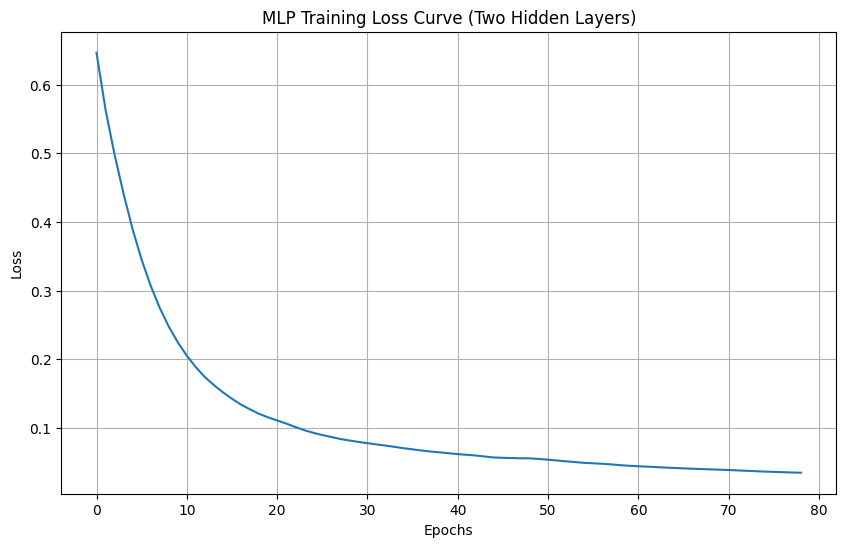

MLP Classifier Accuracy (Two Hidden Layers): 0.9561


In [ ]:
# Run the MLP with hidden_layer_sizes=(50, 50)
mlp_two_layers = MLPClassifier(hidden_layer_sizes=(50, 50), max_iter=500, activation='relu', solver='adam', random_state=42, verbose=False, early_stopping=True, n_iter_no_change=50)
mlp_two_layers.fit(X_train_scaled, y_train)

# Plot the training loss curve
plt.figure(figsize=(10, 6))
plt.plot(mlp_two_layers.loss_curve_)
plt.title('MLP Training Loss Curve (Two Hidden Layers)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Make predictions and evaluate accuracy
y_pred_two_layers = mlp_two_layers.predict(X_test_scaled)
accuracy_two_layers = accuracy_score(y_test, y_pred_two_layers)
print(f"MLP Classifier Accuracy (Two Hidden Layers): {accuracy_two_layers:.4f}")

✅ **Checkpoint**:

1.  Would a CNN or an MLP be more appropriate for classifying microscope images of cells, and why?

2.  What is the main advantage of using multiple hidden layers in an MLP compared to a single hidden layer?

📘 **Learning Rate and Weight Decay -- Two Dials That Control Learning**

The weight-update step described above needs to know *how big* a step to take. Two parameters control this directly:

*   **Learning rate** (`learning_rate_init`, default `0.001`): the size of each weight-update step. Picture the loss curve as a landscape and gradient descent as walking downhill toward its lowest point. A learning rate that is **too small** takes tiny, cautious steps, the network may need far more epochs than `max_iter` allows to get anywhere near the minimum. A learning rate that is **too large** takes steps so big it can overshoot the minimum entirely and bounce around it, or even diverge, with a loss curve that oscillates wildly instead of decreasing smoothly.

*   **Weight decay** (`alpha`, default `0.0001`): a penalty added to the loss for having large weights, formally an L2 regularization term. This is a direct tool against the overfitting problem the "Common mistake" callout raised earlier. A network with very large weights tends to fit the training data's noise very precisely (memorizing rather than generalizing); penalizing large weights during training encourages the network toward simpler, smoother solutions that tend to generalize better to unseen data. Push `alpha` too high, however, and the penalty dominates, the network becomes too constrained to fit even the real signal in the data, and both training and test accuracy suffer together.

Both are hyperparameters you set before training starts, not something the network learns on its own, which is exactly why they are worth deliberately experimenting with rather than leaving at their defaults without a second thought.

🎯 **Predict→Run→Interpret: Learning Rate and Weight Decay**

Before running the cell below, predict: which of the three learning rates listed (very small, default, very large) do you expect to produce the smoothest, most steadily decreasing loss curve? Separately, as `alpha` (weight decay) increases from its default, do you expect the gap between training accuracy and test accuracy to grow or shrink, and why?

#### My Prediction:
*(Write your prediction here, and your reasoning, before running the cell below.)*

In [ ]:
# Part 1: Learning rate comparison
learning_rates = {'Too small (1e-5)': 0.00001, 'Default (1e-3)': 0.001, 'Too large (0.5)': 0.5}

plt.figure(figsize=(10, 6))
for label, lr in learning_rates.items():
    m = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, activation='relu', solver='sgd',
                       learning_rate_init=lr, random_state=42, verbose=False)
    m.fit(X_train_scaled, y_train)
    plt.plot(m.loss_curve_, label=f"{label} -- {len(m.loss_curve_)} epochs")

plt.title('Loss Curve Across Different Learning Rates')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Part 2: Weight decay (alpha) comparison -- watch the train/test accuracy gap
print("\nWeight decay (alpha) vs. the train/test accuracy gap:")
for alpha_val in [0.0001, 0.01, 1.0, 10.0]:
    m = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, activation='relu', solver='adam',
                       alpha=alpha_val, random_state=42, verbose=False, early_stopping=True,
                       n_iter_no_change=50, validation_fraction=0.15)
    m.fit(X_train_scaled, y_train)
    train_acc = accuracy_score(y_train, m.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, m.predict(X_test_scaled))
    print(f"  alpha={alpha_val:<8} train acc: {train_acc:.4f}   test acc: {test_acc:.4f}   gap: {train_acc - test_acc:+.4f}")

✅ **Checkpoint: Learning Rate and Weight Decay**

1.  Which learning rate produced the smoothest loss curve, and which one looked unstable or oscillating? Did any of them fail to converge within the epoch budget given?
2.  Which `alpha` value gave the smallest gap between training and test accuracy? What does a large gap between the two actually represent, and why is a very small gap not automatically the best outcome either?

### Understanding the `MLPClassifier` Parameters (Jargon Buster!)

Let's break down some of the parameters we used in `MLPClassifier` and what they mean:

*   **`hidden_layer_sizes`**: This is a tuple that determines the architecture of your neural network. Each number in the tuple represents the number of neurons (or perceptrons) in a hidden layer. For example, `(100,)` means you have one hidden layer with 100 neurons. `(50, 50)` means two hidden layers, each with 50 neurons. More layers and neurons generally allow the network to learn more complex patterns, but also increase the risk of overfitting and computational cost.
    *   **Biological Analogy**: Think of it as the complexity of the intermediate processing units in a biological system. More hidden layers might correspond to more stages of signal processing in the brain, allowing for more nuanced interpretations of sensory input.

*   **`max_iter`**: This sets the maximum number of `epochs` (complete passes through the entire training dataset). The network iteratively adjusts its weights to minimize the loss. If the loss doesn't improve significantly after a certain number of epochs, `early_stopping` might kick in.

*   **`activation`**: This is the 'firing rule' for each neuron in the hidden layers. It introduces non-linearity into the network, allowing it to learn complex functions. Without activation functions, a multi-layered neural network would simply be equivalent to a single-layered linear model. We'll explore these more below!
    *   **Biological Analogy**: This is like the threshold and response characteristic of a biological neuron. It determines how strongly a neuron 'activates' based on the sum of its inputs.

*   **`solver`**: Which gradient descent strategy is used to update the weights at each step, `'adam'` or `'sgd'` here. See the "How Does a Neural Network Actually Learn?" section above for the full mechanics.

*   **`learning_rate_init`**: The size of each weight-update step taken by the solver. See "Learning Rate and Weight Decay" above.

*   **`alpha`**: The weight decay (L2 regularization) strength. See "Learning Rate and Weight Decay" above.

*   **`validation_fraction`**: The proportion of the training set held out internally as a validation set, used only when `early_stopping=True`. See "Training, Validation, and Test Sets" above.

*   **`random_state`**: Ensures that the initial weights and any random processes during training are reproducible. Setting it to a specific number (like 42) means you'll get the same results every time you run the code.

*   **`verbose`**: If set to `True`, it prints progress messages during training. We set it to `False` to keep the output clean.

*   **`early_stopping`**: A regularization technique to prevent overfitting. If the validation score does not improve for `n_iter_no_change` consecutive epochs, training will stop. This saves computational time and helps to ensure the model generalizes well to new data.
    *   **⚠️ Common mistake**: Not using early stopping can lead to models that perform excellently on training data but poorly on unseen test data, as they've simply memorized the training examples rather than learning general patterns.

### Exploring Activation Functions

Activation functions are crucial components within a neural network, as they introduce non-linearity, allowing the network to learn complex relationships in the data. Without them, a neural network, no matter how many layers it has, would simply behave like a linear model (like logistic regression).

Here are some common activation functions:

*   **`'relu'` (Rectified Linear Unit)**: `f(x) = max(0, x)`. It outputs the input directly if it's positive, otherwise, it outputs zero. This function is very popular due to its computational efficiency and its ability to help mitigate the vanishing gradient problem (where gradients become too small to effectively update weights in deep networks).
    *   **Biological Analogy**: Similar to how a neuron has a firing threshold. If the input signal is below zero, the neuron doesn't fire; if it's above zero, it fires proportionally to the input strength.

*   **`'logistic'` (Sigmoid Function)**: `f(x) = 1 / (1 + exp(-x))`. It squashes any input value into a range between 0 and 1. Historically popular, but can suffer from vanishing gradients for very large or very small inputs.
    *   **Biological Analogy**: Represents the probability of a neuron firing, or the strength of its output signal, ranging from no activation (0) to full activation (1).

*   **`'tanh'` (Hyperbolic Tangent)**: `f(x) = (exp(x) - exp(-x)) / (exp(x) + exp(-x))`. Similar to logistic, but squashes values into a range between -1 and 1. It is zero-centered, which often helps with training stability compared to logistic.
    *   **Biological Analogy**: Similar to sigmoid, but allows for both excitatory (positive) and inhibitory (negative) responses.

🎯 **Predict→Run→Interpret**: Let's experiment with different activation functions. Before running the code below, predict how changing the `activation` from `'relu'` to `'logistic'` or `'tanh'` might affect the loss curve and the final accuracy. Consider the properties of each function described above.

#### My Prediction:

*(Write your prediction here. For example: "I predict that `'logistic'` will... because... and `'tanh'` will... because...")*




--- Training MLP with 'logistic' activation ---


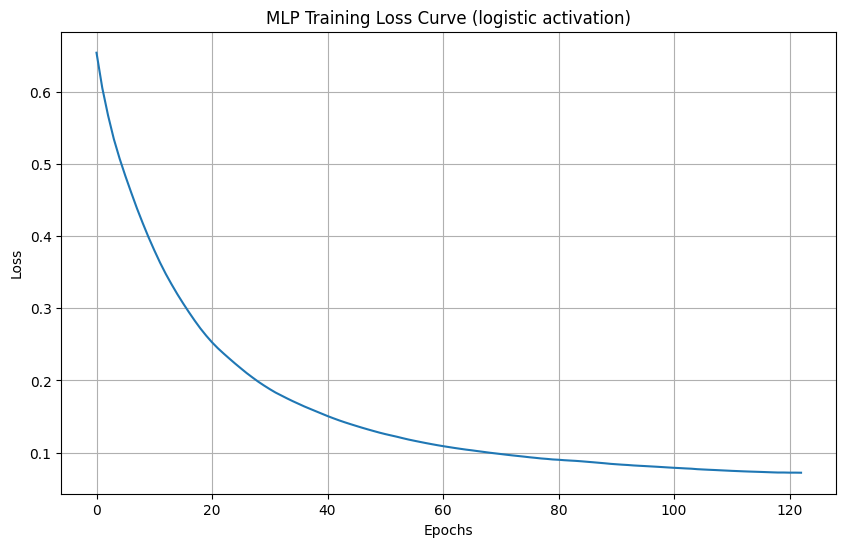

MLP Classifier Accuracy (logistic activation): 0.9561

--- Training MLP with 'tanh' activation ---


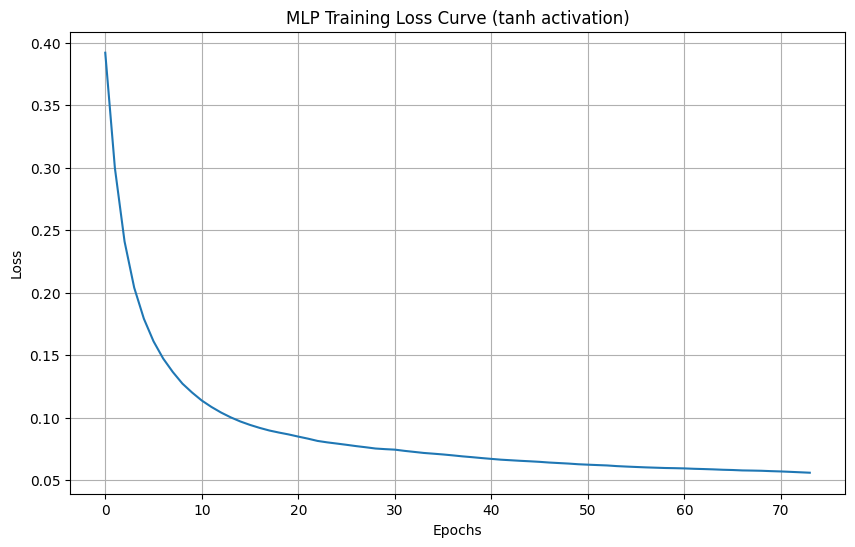

MLP Classifier Accuracy (tanh activation): 0.9737


In [ ]:
# Experiment with 'logistic' activation
print("\n--- Training MLP with 'logistic' activation ---")
mlp_logistic = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, activation='logistic', solver='adam', random_state=42, verbose=False, early_stopping=True, n_iter_no_change=50)
mlp_logistic.fit(X_train_scaled, y_train)

plt.figure(figsize=(10, 6))
plt.plot(mlp_logistic.loss_curve_)
plt.title('MLP Training Loss Curve (logistic activation)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

y_pred_logistic = mlp_logistic.predict(X_test_scaled)
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
print(f"MLP Classifier Accuracy (logistic activation): {accuracy_logistic:.4f}")


# Experiment with 'tanh' activation
print("\n--- Training MLP with 'tanh' activation ---")
mlp_tanh = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, activation='tanh', solver='adam', random_state=42, verbose=False, early_stopping=True, n_iter_no_change=50)
mlp_tanh.fit(X_train_scaled, y_train)

plt.figure(figsize=(10, 6))
plt.plot(mlp_tanh.loss_curve_)
plt.title('MLP Training Loss Curve (tanh activation)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

y_pred_tanh = mlp_tanh.predict(X_test_scaled)
accuracy_tanh = accuracy_score(y_test, y_pred_tanh)
print(f"MLP Classifier Accuracy (tanh activation): {accuracy_tanh:.4f}")

### How to Select an Appropriate Activation Function?

Choosing the 'best' activation function often involves some experimentation, but here are some general guidelines:

1.  **For Hidden Layers**: `'relu'` is typically the default choice for hidden layers due to its computational efficiency and effectiveness in preventing vanishing gradients in deep networks. Its variants (e.g., Leaky ReLU, ELU) are also popular.
2.  **For Output Layers**: The choice depends on the type of problem:
    *   **Binary Classification**: `'logistic'` (sigmoid) is common, as it outputs a probability between 0 and 1.
    *   **Multiclass Classification**: For problems with more than two classes, you'd typically use `softmax` (which is not directly an `activation` parameter in `MLPClassifier` but handled by setting `loss='log_loss'` and the number of output neurons).
    *   **Regression**: A linear activation (no activation function, or `identity`) is used, as you want to predict a continuous value without bounding it.

In `MLPClassifier`, for binary classification problems like our Breast Cancer dataset, the output layer implicitly uses a logistic activation if there are two classes and `loss='log_loss'` (the default for classification). The `activation` parameter you set applies only to the hidden layers.

**Key takeaway**: Start with `'relu'` for hidden layers, especially if you're unsure. If you encounter issues (like dead neurons), you might explore `tanh` or other ReLU variants. The output layer's activation is primarily determined by your task (classification vs. regression).

### Review & Practice: Module 8 Checkpoint

This section helps you consolidate your understanding of Module 8. Answer the questions below, referring back to the module content if needed.

✅ **Checkpoint**:

1.  You are building a neural network to predict whether a gene sequence contains a specific regulatory element. Which type of neural network (MLP, CNN, or RNN) would likely be most appropriate, and why?

2.  What is the primary advantage of using a non-linear activation function (like ReLU or tanh) in the hidden layers of an MLP compared to using a linear activation function?

3.  Why is it important to standardize your input data (like with `StandardScaler`) before training an MLP, especially with activation functions like `tanh` or `logistic`?
3.  Why can't the internal validation set used for early stopping be the same data as your final test set?
4.  If a loss curve oscillates wildly instead of decreasing smoothly, which hyperparameter would you investigate first, and why?

## Module 9 — A Taste of NLP in Biology

**Learning Objective**: See how AI works on text, not just numbers.

📘 **Natural Language Processing (NLP)**

Up until now, we've focused on structured numerical data. But a vast amount of biological information exists as text, such as scientific articles, patent documents, clinical notes, and gene descriptions. **Natural Language Processing (NLP)** is a field of AI that gives computers the ability to understand, process, and generate human language.

At its core, NLP involves transforming raw text (which computers don't natively understand) into numerical representations that machine learning models can process. This often starts with breaking down sentences into words or sub-word units, a process called **tokenization**.

For example, if you have a scientific abstract, NLP can help you automatically extract key findings, identify protein-protein interactions mentioned, or summarize complex research papers, saving researchers countless hours.

📘 **Bag-of-Words and TF-IDF**

Once text is tokenized, we need ways to represent these words numerically. Two fundamental techniques are **Bag-of-Words (BoW)** and **TF-IDF (Term Frequency-Inverse Document Frequency)**.

*   **Bag-of-Words**: This is a simple representation where a text (like a document or an abstract) is represented as a 'bag' of its words, disregarding grammar and word order but keeping track of word frequencies. Imagine counting how many times each word appears in a research paper. The presence or absence of specific words (and their counts) can be very informative.
    *   **Biological Analogy**: Similar to identifying an organism by the types and counts of genes it possesses, without necessarily considering the exact order or chromosomal location of those genes.

*   **TF-IDF**: This technique goes a step further than simple word counts. It assigns a weight to each word that signifies its importance to a document in a collection or corpus. Words that appear frequently in a specific document but rarely across many documents (like 'CRISPR' in a genetics paper) get a high TF-IDF score, indicating they are more relevant to that document. Words that are common everywhere (like 'the', 'is', 'of') get low scores.
    *   **Biological Analogy**: Consider a genetic mutation. If a mutation appears frequently in a specific disease cohort but is rare in the general population, it becomes highly significant (high TF-IDF). A common polymorphism present in almost everyone has low significance.

📘 **Text Mining in Literature Review**

**Text mining** in bioinformatics involves applying NLP techniques to biological and medical literature. This can help researchers discover new relationships between genes and diseases, identify drug targets, or keep up with the explosion of scientific publications.

For example, text mining can automatically scan thousands of PubMed abstracts to:
*   Identify all proteins mentioned in the context of a specific disease.
*   Discover potential drug interactions.
*   Find papers discussing novel therapeutic approaches.

This process is like having a tireless assistant who can read and cross-reference an entire library of scientific literature for you, much faster and more systematically than a human ever could.

🔬 **Why this matters in biology**: The volume of biological literature is now far beyond what any single researcher can read. PubMed alone adds thousands of new papers every day. Text mining tools built on exactly the TF-IDF and classification techniques above are what let researchers triage that volume automatically, for example flagging the subset of new papers relevant to a specific gene, pathway, or organism, before anyone has to read a single abstract by hand.

In [ ]:
# Load necessary libraries for NLP
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset: Small Hardcoded PubMed Abstract Snippets

To demonstrate NLP without requiring external data or API keys, we'll create a small, hardcoded dataset of abstract titles/snippets. We'll simulate two contrasting topics: **'Cyanobacteria Research'** and **'Cancer Therapy'**.

In [ ]:
# Define two sets of abstract snippets for different topics
cyanobacteria_abstracts = [
    "Photosynthesis and nitrogen fixation in cyanobacteria: a review of metabolic pathways and environmental adaptation.",
    "Genomic analysis of Synechocystis PCC 6803 reveals novel pathways for carbon sequestration.",
    "Biofuel production from marine cyanobacteria: challenges and opportunities.",
    "Ecological role of harmful cyanobacterial blooms in freshwater ecosystems.",
    "Influence of light intensity on growth and pigment production in Spirulina.",
    "Engineering cyanobacteria for enhanced hydrogen production.",
    "Molecular mechanisms of stress tolerance in thermophilic cyanobacteria.",
    "Cyanobacterial toxins: detection, effects, and public health implications.",
    "Comparative genomics of nitrogen-fixing cyanobacteria.",
    "Role of circadian rhythms in cyanobacterial metabolism."
]

cancer_abstracts = [
    "Targeting EGFR in non-small cell lung cancer: current strategies and future directions.",
    "Immunotherapy for metastatic melanoma: PD-1 blockade and combination therapies.",
    "CRISPR-Cas9 gene editing as a therapeutic approach for hereditary cancers.",
    "Novel chemotherapy agents for triple-negative breast cancer.",
    "Precision medicine in oncology: genomic profiling to guide treatment decisions.",
    "Understanding tumor microenvironment interactions in colorectal cancer progression.",
    "Radiotherapy combined with immune checkpoint inhibitors in solid tumors.",
    "Biomarkers for early detection of ovarian cancer.",
    "Development of CAR T-cell therapy for hematological malignancies.",
    "Epigenetic modifications as therapeutic targets in prostate cancer."
]

# Combine and create labels
documents = cyanobacteria_abstracts + cancer_abstracts
labels = ['Cyanobacteria'] * len(cyanobacteria_abstracts) + ['Cancer'] * len(cancer_abstracts)

df = pd.DataFrame({'text': documents, 'topic': labels})
print(df.head())
print(df.tail())

                                                text          topic
0  Photosynthesis and nitrogen fixation in cyanob...  Cyanobacteria
1  Genomic analysis of Synechocystis PCC 6803 rev...  Cyanobacteria
2  Biofuel production from marine cyanobacteria: ...  Cyanobacteria
3  Ecological role of harmful cyanobacterial bloo...  Cyanobacteria
4  Influence of light intensity on growth and pig...  Cyanobacteria
                                                 text   topic
15  Understanding tumor microenvironment interacti...  Cancer
16  Radiotherapy combined with immune checkpoint i...  Cancer
17  Biomarkers for early detection of ovarian cancer.  Cancer
18  Development of CAR T-cell therapy for hematolo...  Cancer
19  Epigenetic modifications as therapeutic target...  Cancer


### Task: TF-IDF Vectorization and Simple Classifier

We will now convert our text snippets into numerical features using TF-IDF and then train a simple `LogisticRegression` classifier to distinguish between the two topics. This is a basic example of **text classification**.

In [ ]:
# Split data into training and testing sets
X_train_text, X_test_text, y_train_topic, y_test_topic = train_test_split(df['text'], df['topic'], test_size=0.3, random_state=42, stratify=df['topic'])

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=100) # Limit features for simplicity

# Fit and transform the training data, then transform the test data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(f"TF-IDF training data shape: {X_train_tfidf.shape}")
print(f"TF-IDF testing data shape: {X_test_tfidf.shape}")

# Train a Logistic Regression classifier
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train_tfidf, y_train_topic)

# Make predictions and evaluate
y_pred_topic = classifier.predict(X_test_tfidf)
accuracy_topic = accuracy_score(y_test_topic, y_pred_topic)

print(f"\nClassifier Accuracy: {accuracy_topic:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_topic, y_pred_topic))

TF-IDF training data shape: (14, 94)
TF-IDF testing data shape: (6, 94)

Classifier Accuracy: 0.8333

Classification Report:
               precision    recall  f1-score   support

       Cancer       1.00      0.67      0.80         3
Cyanobacteria       0.75      1.00      0.86         3

     accuracy                           0.83         6
    macro avg       0.88      0.83      0.83         6
 weighted avg       0.88      0.83      0.83         6



🎯 **Predict→Run→Interpret**: The `LogisticRegression` model has learned to classify topics. Before running the next cell, try to guess which words (features) received the highest TF-IDF scores and would be most influential in differentiating 'Cyanobacteria' from 'Cancer' topics. Consider words that are highly specific to each domain.

#### My Prediction:

*(Write your prediction here. For example: "I predict that words like 'photosynthesis' and 'genome' will be important for cyanobacteria, and 'tumor' and 'therapy' for cancer.")*



In [ ]:
# Get feature names (words) from the TF-IDF vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Get the coefficients from the trained Logistic Regression model
# The coefficients represent the importance of each feature for classification
# For binary classification, positive coefficients lean towards one class, negative towards the other.
coefficients = classifier.coef_[0]

# Create a DataFrame to easily sort and view words and their importance
word_importance = pd.DataFrame({'word': feature_names, 'coefficient': coefficients})

# Sort by coefficient to see most influential words for each topic
# (Assuming 'Cancer' is the positive class, 'Cyanobacteria' is negative, based on `classifier.classes_`)
print(f"Classifier classes (internal order for coefficients): {classifier.classes_}")

print("\nTop words predicting 'Cyanobacteria' topic (positive coefficients):")
print(word_importance.sort_values(by='coefficient', ascending=False).head(10).to_string(index=False))

print("\nTop words predicting 'Cancer' topic (negative coefficients):")
print(word_importance.sort_values(by='coefficient', ascending=True).head(10).to_string(index=False))

Classifier classes (internal order for coefficients): ['Cancer' 'Cyanobacteria']

Top words predicting 'Cyanobacteria' topic (positive coefficients):
          word  coefficient
 cyanobacteria     0.364128
    production     0.271492
cyanobacterial     0.258347
      nitrogen     0.251772
      pathways     0.209149
            of     0.190517
      enhanced     0.181943
      hydrogen     0.181943
   engineering     0.181943
        fixing     0.174214

Top words predicting 'Cancer' topic (negative coefficients):
         word  coefficient
       cancer    -0.414331
         cell    -0.238933
           as    -0.238727
  therapeutic    -0.238727
        early    -0.181921
   biomarkers    -0.181921
      ovarian    -0.181921
          for    -0.179818
hematological    -0.158420
 malignancies    -0.158420


#### Interpretation of TF-IDF Coefficients (Corrected Labels)

As noted in the previous output, the `LogisticRegression` model orders its classes alphabetically by default if not specified otherwise. In this case, `classifier.classes_` is `['Cancer', 'Cyanobacteria']`. The coefficients in `classifier.coef_[0]` correspond to the probability of the **second class** (`'Cyanobacteria'`).

Therefore:
*   **Positive coefficients** mean the word strongly predicts the **`'Cyanobacteria'`** topic.
*   **Negative coefficients** mean the word strongly predicts the **`'Cancer'`** topic.



### Review & Practice: Module 9 Checkpoint

This section helps you consolidate your understanding of Module 9. Answer the questions below, referring back to the module content if needed.

✅ **Checkpoint**:

1.  Which words carried the most weight in separating the two topics ('Cyanobacteria' vs. 'Cancer') based on the TF-IDF and Logistic Regression analysis? Does this match your own reading of the abstracts?

2.  Imagine you are studying a new virus and want to quickly find all PubMed articles that discuss its interaction with human proteins. Which NLP concept (tokenization, Bag-of-Words, TF-IDF, or text mining) is most directly applicable to this task, and why?

3.  What is the main difference between Bag-of-Words and TF-IDF in how they represent the importance of a word in a document?

## Session 6 — Reinforcement Learning, Ethics, Capstone

## Module 10 — A Taste of Reinforcement Learning

**Learning Objective**: Understand the RL loop (agent, environment, action, reward) without heavy math.

📘 **The Reinforcement Learning (RL) Loop**

Reinforcement Learning is a paradigm of machine learning where an **agent** learns to make decisions by performing **actions** in an **environment** to maximize some notion of cumulative **reward**. Unlike supervised learning, there are no 'correct' input/output pairs; instead, the agent learns through trial and error, much like how an animal learns to find food.

Imagine you are training a new cell culture protocol. You try different media formulations, temperatures, or CO2 levels (actions). The growth rate of your cells (reward) tells you if you made a good choice. The next time, you adjust your actions based on past experience. This continuous cycle of observation, action, and reward is the essence of the RL loop:

1.  **Environment**: The world the agent interacts with (e.g., your bioreactor, a virtual maze).
2.  **Agent**: The learner or decision-maker (e.g., the AI algorithm controlling the bioreactor, a virtual robot).
3.  **Action**: What the agent does in the environment (e.g., changing temperature, adding nutrients).
4.  **State**: The current situation of the environment observed by the agent (e.g., current cell density, nutrient levels).
5.  **Reward**: A numerical signal indicating how good or bad an action was (e.g., higher cell count, successful navigation).

The agent's goal is to learn a **policy**, which is a strategy that maps states to actions, to maximize its total reward over time.

📘 **Multi-Armed Bandit (MAB) Problem**

The **Multi-Armed Bandit (MAB)** problem is one of the simplest and most intuitive settings in Reinforcement Learning. Imagine you're at a casino facing multiple slot machines (one-armed bandits), each with a different, unknown probability distribution of payouts. Your goal is to figure out which machine gives the best average payout and then play that machine as much as possible to maximize your total winnings. You have to balance between:

*   **Exploration**: Trying out different machines to learn about their payouts.
*   **Exploitation**: Playing the machine you currently believe is the best to maximize immediate reward.

This is a classic **exploration-exploitation dilemma**, a fundamental challenge in RL. Too much exploration means you might waste time on bad machines; too much exploitation means you might miss out on a better machine you haven't fully explored.

🔬 **Why this matters in biology**: This framework is directly analogous to optimizing experimental conditions in a lab. For example, you might be testing 3 different growth media formulations for a bacterial strain. Each formulation has a 'true' (but unknown to you) average growth yield. You want to quickly identify the best medium without running too many experiments on suboptimal ones. The MAB algorithm helps you make sequential decisions on which medium to try next, balancing learning which is best (exploration) with using the best one found so far (exploitation).

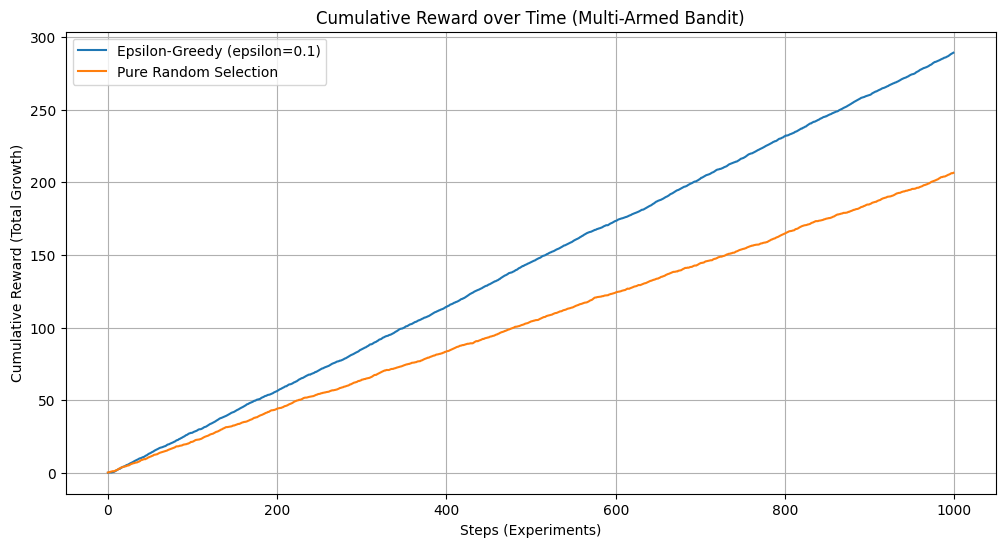

Final estimates for Epsilon-Greedy agent: [0.09405697 0.3015287  0.21551721]
True rewards: [0.1, 0.3, 0.2]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulation Setup ---
# Define the true (hidden) average rewards for 3 different "media formulations" (arms)
true_rewards = [0.1, 0.3, 0.2] # e.g., average cell growth rates
n_arms = len(true_rewards)

# Number of steps (experiments) to run
n_steps = 1000

# Epsilon for epsilon-greedy strategy
epsilon = 0.1 # 10% chance of exploring (trying a random arm)

# Keep track of rewards and plays for each arm
estimates = np.zeros(n_arms) # Our current estimate of each arm's average reward
counts = np.zeros(n_arms)    # How many times we've played each arm

# Store total rewards for plotting
rewards_epsilon_greedy = []
rewards_random = []

# --- Epsilon-Greedy Agent ---
for step in range(n_steps):
    if np.random.rand() < epsilon: # Explore
        chosen_arm = np.random.randint(n_arms)
    else: # Exploit
        chosen_arm = np.argmax(estimates)

    # Simulate pulling the chosen arm and getting a reward
    # Reward is simulated by drawing from a normal distribution around the true_reward
    reward = np.random.normal(true_rewards[chosen_arm], 0.1) # 0.1 is standard deviation

    # Update estimates
    counts[chosen_arm] += 1
    estimates[chosen_arm] = estimates[chosen_arm] + (reward - estimates[chosen_arm]) / counts[chosen_arm]

    rewards_epsilon_greedy.append(reward)


# --- Pure Random Selection (Baseline) ---
for step in range(n_steps):
    chosen_arm_random = np.random.randint(n_arms)
    reward_random = np.random.normal(true_rewards[chosen_arm_random], 0.1)
    rewards_random.append(reward_random)


# --- Plotting Cumulative Rewards ---
plt.figure(figsize=(12, 6))
plt.plot(np.cumsum(rewards_epsilon_greedy), label=f'Epsilon-Greedy (epsilon={epsilon})')
plt.plot(np.cumsum(rewards_random), label='Pure Random Selection')
plt.title('Cumulative Reward over Time (Multi-Armed Bandit)')
plt.xlabel('Steps (Experiments)')
plt.ylabel('Cumulative Reward (Total Growth)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final estimates for Epsilon-Greedy agent: {estimates}")
print(f"True rewards: {true_rewards}")

🎯 **Predict→Run→Interpret**: In the simulation above, we used an `epsilon` of 0.1 (10% exploration). How do you think the cumulative reward curve would change if we set `epsilon` to 0.0 (pure exploitation after initial estimates) or 0.5 (more exploration)? Write your prediction, then modify and re-run the code to observe the difference.

#### My Prediction:

*(Write your prediction here. For example: "If `epsilon` is 0.0, the agent will... resulting in... If `epsilon` is 0.5, it will... leading to...")*



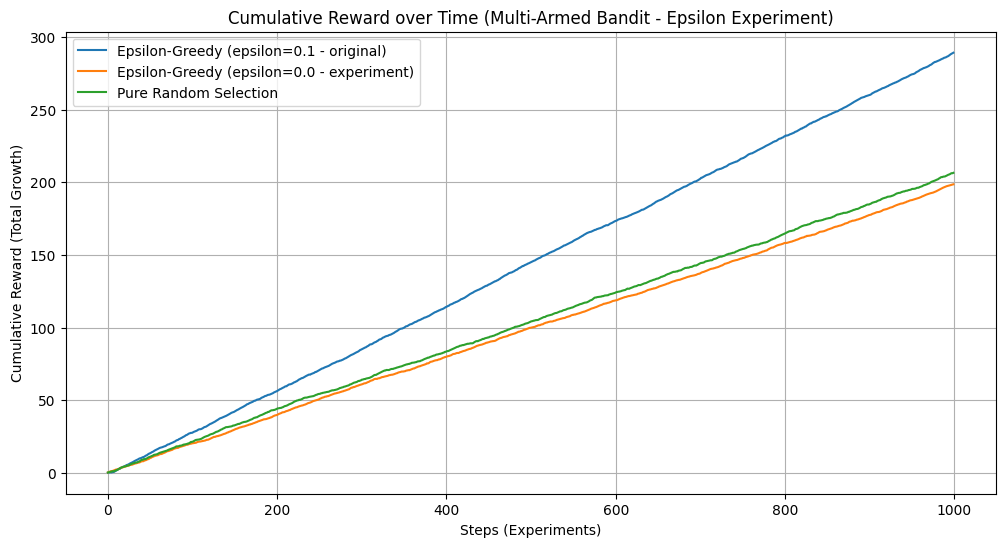

Final estimates for Epsilon-Greedy agent (epsilon=0.0): [0.         0.         0.19862114]
True rewards: [0.1, 0.3, 0.2]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulation Setup ---
true_rewards = [0.1, 0.3, 0.2]
n_arms = len(true_rewards)
n_steps = 1000

# Experiment with a different epsilon value
epsilon_experiment = 0.0 # Try 0.0 for pure exploitation, or 0.5 for more exploration

estimates_exp = np.zeros(n_arms)
counts_exp = np.zeros(n_arms)
rewards_epsilon_greedy_exp = []

for step in range(n_steps):
    if np.random.rand() < epsilon_experiment: # Explore
        chosen_arm_exp = np.random.randint(n_arms)
    else: # Exploit
        # Handle case where counts_exp are all zero initially (no estimates yet)
        if np.all(counts_exp == 0):
            chosen_arm_exp = np.random.randint(n_arms) # Random choice if no data yet
        else:
            chosen_arm_exp = np.argmax(estimates_exp)

    reward_exp = np.random.normal(true_rewards[chosen_arm_exp], 0.1)

    counts_exp[chosen_arm_exp] += 1
    estimates_exp[chosen_arm_exp] = estimates_exp[chosen_arm_exp] + (reward_exp - estimates_exp[chosen_arm_exp]) / counts_exp[chosen_arm_exp]

    rewards_epsilon_greedy_exp.append(reward_exp)


# --- Plotting Cumulative Rewards for comparison ---
plt.figure(figsize=(12, 6))
plt.plot(np.cumsum(rewards_epsilon_greedy), label=f'Epsilon-Greedy (epsilon=0.1 - original)')
plt.plot(np.cumsum(rewards_epsilon_greedy_exp), label=f'Epsilon-Greedy (epsilon={epsilon_experiment} - experiment)')
plt.plot(np.cumsum(rewards_random), label='Pure Random Selection')
plt.title('Cumulative Reward over Time (Multi-Armed Bandit - Epsilon Experiment)')
plt.xlabel('Steps (Experiments)')
plt.ylabel('Cumulative Reward (Total Growth)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final estimates for Epsilon-Greedy agent (epsilon={epsilon_experiment}): {estimates_exp}")
print(f"True rewards: {true_rewards}")

### Review & Practice: Module 10 Checkpoint

This section helps you consolidate your understanding of Module 10. Answer the questions below, referring back to the module content if needed.

✅ **Checkpoint**:

1.  How is this Reinforcement Learning (Multi-Armed Bandit) problem different from the supervised learning you did in Module 4?

2.  Who provides the 'labels' (or feedback) in the Multi-Armed Bandit problem, and how is this different from how labels are provided in a classification task?

3.  Why is the 'exploration-exploitation dilemma' a critical consideration in setting up an experiment to optimize a bioreactor's conditions using an RL approach?

## Module 11 — Ethical and Societal Considerations (no code)

**Learning Objective**: Reflect, not compute.

📘 **Bias in Training Data**

One of the most critical ethical concerns in AI is **bias in training data**. If the data used to train an AI model is not representative of the real world, the model can perpetuate or even amplify existing societal biases. In bioinformatics and healthcare, this can have serious consequences. For instance, if a diagnostic AI for skin conditions is primarily trained on images of fair skin, it may perform poorly or inaccurately on individuals with darker skin tones, leading to misdiagnosis or delayed treatment. Similarly, genomic datasets often have an overrepresentation of individuals of European descent, which can lead to AI models that are less effective at predicting disease risk or drug response in underrepresented populations.

🔬 **Why this matters in biology**: AI models trained on biased biomedical data could exacerbate health disparities, making healthcare less equitable. Ensuring diversity in data collection is not just an ethical imperative but also crucial for building robust and universally applicable AI tools in medicine and biology.

📘 **Reproducibility and Data Provenance**

In scientific research, **reproducibility** is paramount – the ability for other researchers to independently replicate the methods and results of a study. With AI, this becomes complex. The exact performance of an AI model can depend on subtle choices in data preprocessing, model architecture, hyperparameters, and even the random seed. **Data provenance** (the origin and history of data) is also crucial. Knowing exactly where the training data came from, how it was collected, and what transformations it underwent is essential for validating AI findings. Lack of transparency here can lead to 'black box' issues, where it's hard to trust or verify the model's conclusions.

🔬 **Why this matters in biology**: Imagine an AI suggesting a novel drug target based on complex gene expression data. If the AI's development process isn't transparent and reproducible, other scientists cannot verify its findings, hindering further research and potential therapeutic development. Reproducibility ensures trust and accelerates scientific progress.

📘 **Dual-Use Concerns and Over-Trust in 'Black Box' Predictions**

AI, like many powerful technologies, can have **dual-use concerns**, meaning it can be used for both beneficial and harmful purposes. For example, AI designed to predict viral mutations for vaccine development could potentially be repurposed for designing bioweapons. This highlights the need for careful consideration of potential misuse.

Furthermore, there's a risk of **over-trust in 'black box' predictions**, especially in critical domains like clinical settings. Many advanced AI models (like deep neural networks) are highly complex, making it difficult for humans to understand *why* they make a particular prediction. If a clinician relies blindly on an AI's diagnosis without understanding its rationale or limitations, it could lead to incorrect medical decisions, particularly when the AI encounters data outside its training distribution or makes a subtle error.

⚠️ **Common mistake**: Blindly trusting an AI model's output without critically evaluating its context, the data it was trained on, or its explainability can be dangerous. Always consider the potential for error and bias.

📘 **Data Privacy in Genomic Data**

Genomic data is inherently sensitive, containing unique and identifiable information about an individual and their family. Applying AI to genomic data raises significant **data privacy** concerns. Even if data is anonymized, it can sometimes be re-identified by combining it with other publicly available information. Protecting this data is crucial to prevent discrimination (e.g., by insurance companies or employers), ensure personal autonomy, and maintain public trust in scientific research.

🔬 **Why this matters in biology**: As AI gets better at extracting insights from genomic data, the ethical obligation to protect individual privacy becomes even more acute. Innovations like federated learning (where models learn from decentralized data without sharing raw data) are emerging to address these challenges, allowing AI to benefit from large datasets while preserving privacy.

### Task: Written Reflection

Based on the concepts discussed above, write a 3-5 sentence reflection on one ethical risk specific to applying the breast-cancer classifier from Module 5 (or Module 8, the MLP version) in a real clinical pipeline. Consider how you might mitigate this risk.

*(Write your reflection here)*

### Review & Practice: Module 11 Checkpoint

This section helps you consolidate your understanding of Module 11. Answer the questions below, referring back to the module content if needed.

✅ **Checkpoint**:

1.  A new AI model is developed to predict the efficacy of personalized cancer treatments. However, its training data primarily consists of patients from high-income countries. What ethical risk does this pose, and what could be a consequence for patients in lower-income regions?

2.  You are a bioinformatician asked to develop an AI model to analyze sensitive patient health records. What is the primary ethical concern you should address before even starting data collection or model training?

3.  Why is it problematic to treat an advanced AI model that predicts disease outcomes as a 'black box' in a clinical setting, even if it has very high accuracy?

## Module 12 — Capstone: End-to-End Pipeline

**Learning Objective**: Integrate everything from this notebook series without step-by-step hand-holding, on a real dataset you find yourself, and be able to defend every choice you made when asked live at your viva.

### Task: Build Your Own ML Pipeline

This Capstone is an independent assessment of your understanding of the entire workflow covered across Modules 0-11. Unlike every earlier module, there is no provided dataset and no scaffolded code. You choose the data, you choose the approach, and you defend both.

---

#### Step 0: Find Your Own Dataset

You may **not** use `load_iris()`, `load_breast_cancer()`, `load_wine()`, `load_digits()`, or `load_diabetes()`. You have already seen how each of those behaves, in this notebook and in class, which means using one again would not actually test whether you can handle data you have never met before.

Instead, find a real dataset with at least one biological or clinical dimension from a public source such as:

* **UCI Machine Learning Repository** (archive.ics.uci.edu) — search for terms like "cancer," "gene expression," "diabetes," or "protein"
* **Kaggle Datasets** (kaggle.com/datasets) — search similarly, and prefer datasets with a clear description of what each column means
* A public **GEO** series (ncbi.nlm.nih.gov/geo) if you want a genomics-flavored challenge, though these often need more cleaning

A plain CSV file is enough. Most of these sites let you download one directly, which you can then load with `pd.read_csv('your_file.csv')` after uploading it to your Colab session (Files panel on the left, or `from google.colab import files; files.upload()`).

Real data will not arrive as clean as Iris did. Expect actual missing values, categorical columns that need encoding, and a target variable that is not perfectly balanced. That is the point.

---

#### Step 1: Pre-Register Your Hypothesis

Before you run any exploratory analysis, write a markdown cell stating what you expect to find, based only on the column names and your own domain reasoning, biological or general. For example: "I expect BMI and age to be the strongest predictors, because metabolic disease risk is known to correlate with both." You will compare this prediction against your actual results in Step 8, so be specific enough that you could be proven wrong.

---

#### Step 2: Load & Explore Data

Load your dataset into a Pandas DataFrame. Perform EDA using `.head()`, `.info()`, `.describe()`, and visualize key features or relationships (histograms, scatter plots, pairplots, correlation heatmaps, whichever fit your data).

---

#### Step 3: Preprocessing & Scaling

Handle any missing values and encode any categorical features. Apply appropriate scaling (`StandardScaler` or `MinMaxScaler`) to your numeric features. Perform a train-test split (`test_size=0.2`, `random_state=42`).

---

#### Step 4: Choose ML Task & Justify

In a markdown cell, state whether your dataset is best suited to a supervised task (classification or regression) or an unsupervised task (clustering), and briefly justify why, given what your data actually looks like.

---

#### Step 5: Model Training with Cross-Validation and Hyperparameter Search

Select at least two different models appropriate for your task. For each model:

* Evaluate it using **5-fold cross-validation** (`cross_val_score`, as in Module 4) rather than a single train-test split, and report the mean and standard deviation across folds.
* Run at least one **hyperparameter search** (`GridSearchCV` or `RandomizedSearchCV`) over a small, sensible parameter grid. In a markdown cell, briefly justify why you chose the parameters and ranges you searched over.

---

#### Step 6: Evaluation with Correct Metrics

Evaluate your best model (from the hyperparameter search) on the held-out test set, using metrics appropriate for your task: for classification, accuracy, confusion matrix, classification report, and ROC AUC where applicable; for regression, R-squared, MSE, and RMSE; for clustering, silhouette score, and adjusted Rand index if you have true labels to compare against.

---

#### Step 7: Failure Analysis

Identify at least three specific samples your model got wrong (misclassified samples for classification, or the highest-residual predictions for regression). Look at what those specific rows actually contain. In a markdown cell, discuss what these particular failures have in common, if anything, and what that suggests about your model's blind spots. A summary metric alone does not satisfy this step; you need to point at specific rows and explain them.

---

#### Step 8: Interpret Results and Revisit Your Hypothesis

In a markdown cell, write a 5-8 sentence interpretation of your results. Discuss which model performed better and why you think that might be the case, what your failure analysis revealed, and explicitly state whether your Step 1 hypothesis was correct, partially correct, or wrong, and why.

---

#### A note on your viva

You will defend this project live, briefly, at your capstone viva. I will ask you to explain specific choices on the spot, and I may hand you a small unfamiliar dataset and ask how you would adapt your own pipeline to it, without running new code. A notebook that runs correctly but that you cannot explain will not do well at the viva regardless of its output, so build this in a way you genuinely understand, not just in a way that produces a good-looking result.